# Figure 3 - Falsifying Simple Explanations of Plasticity Loss

Section 5.1 of the paper asks whether plasticity loss can be explained away by a single, easy-to-compute network statistic. Four candidates are tested: **weight norm**, **weight rank**, the fraction of **dead ReLU units**, and **feature rank** (the rank of the penultimate-layer representation).

The protocol: train a DQN agent on one of the three classification MDPs (`easy`, `hard`, `sparse`), and every `probe_every` optimizer steps, pause training to (a) run the random-target plasticity probe from Section 2.2 and (b) recompute all four statistics on the current network. If a statistic really explained plasticity loss, its correlation with plasticity loss should be consistently strong and same-signed across every controlled comparison (observation space, architecture, or environment). The paper's finding is that it isn't — this notebook lets you check that directly on the correlation table below.

This notebook builds the experiment inline from the shared building blocks in `src/experiments/` (DQN loop, plasticity probe, and the four statistic functions), rather than delegating to a wrapper module, so every knob is visible and editable here.

In [1]:
import os
from pathlib import Path

import src

ROOT = Path(src.__file__).resolve().parent.parent
DATA_ROOT = ROOT / "data"
OUTPUT_ROOT = ROOT / "outputs"
FIGURES_DIR = OUTPUT_ROOT / "figures"
TABLES_DIR = OUTPUT_ROOT / "tables"
CHECKPOINTS_DIR = OUTPUT_ROOT / "checkpoints"
for directory in (OUTPUT_ROOT, FIGURES_DIR, TABLES_DIR, CHECKPOINTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

MPLCONFIGDIR = OUTPUT_ROOT / "matplotlib_cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

ROOT

PosixPath('/Users/mahdigheidi/Documents/Univ/Masters-Study-Project')

## Imports

Everything below comes from the reusable building blocks in `src/`: the shared DQN training loop (`src.experiments.dqn_classification`), the replay buffer (`src.agents.replay_buffer`), the random-target plasticity probe (`src.experiments.plasticity`), and the four candidate statistics (`weight_norm`, `weight_rank`, `dead_units`, `feature_rank`). The experiment-specific logic — how to combine them into Figure 3's train-probe-record loop — lives in this notebook.

In [2]:
import copy
from dataclasses import asdict, dataclass, replace
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd

from src.experiments.dead_units import compute_dead_units
from src.experiments.dqn_classification import (
    DEVICE,
    ClassificationDQNConfig,
    build_environment,
    build_model_factory,
    build_optimizer,
    collect_transition,
    epsilon_at_step,
    load_dataset,
    optimizer_factory_from_config,
    set_seed,
    train_dqn_step,
)
from src.agents.replay_buffer import ReplayBuffer
from src.experiments.feature_rank import compute_model_feature_rank
from src.experiments.plasticity import PlasticityProbeConfig, estimate_probe_loss
from src.experiments.weight_norm import compute_weight_norm
from src.experiments.weight_rank import compute_weight_rank

DEVICE

device(type='cpu')

## Run Configuration

`Figure3RunConfig` extends the shared DQN config with the extra knobs this experiment needs: how often to pause and probe (`probe_every`), and the probe's own step/task/batch-size budget. `FIGURE3_SCHEMA` fixes the column order of the summary table produced below.

In [3]:
@dataclass
class Figure3RunConfig(ClassificationDQNConfig):
    probe_every: int = 5_000
    probe_steps: int = 2_000
    num_probe_tasks: int = 10
    probe_batch_size: int = 512
    metric_batch_size: int = 512


FIGURE3_SCHEMA = [
    "run_id",
    "seed",
    "observation_space",
    "environment",
    "architecture",
    "optimizer",
    "step",
    "probe_loss",
    "initial_probe_loss",
    "plasticity_loss",
    "weight_norm",
    "weight_rank",
    "dead_units",
    "feature_rank",
]

## Panel Definitions

Figure 3 renders one scatter panel per statistic. Each panel holds one variable fixed (e.g. weight-norm's panel compares `mnist` vs. `cifar10` while everything else is held at its default) so a real explanatory statistic would have to show a consistent correlation *within* every condition, not just on average.

In [4]:
@dataclass(frozen=True)
class PanelSpec:
    panel: str
    title: str
    x_column: str
    x_label: str
    condition_column: str
    conditions: Tuple[str, ...]


PANEL_SPECS: Tuple[PanelSpec, ...] = (
    PanelSpec(
        panel="weight_norm",
        title="Varying observation space",
        x_column="weight_norm",
        x_label="Weight norm",
        condition_column="observation_space",
        conditions=("cifar10", "mnist"),
    ),
    PanelSpec(
        panel="weight_rank",
        title="Varying observation space",
        x_column="weight_rank",
        x_label="Weight rank",
        condition_column="observation_space",
        conditions=("cifar10", "mnist"),
    ),
    PanelSpec(
        panel="dead_units",
        title="Varying architecture",
        x_column="dead_units",
        x_label="Dead units",
        condition_column="architecture",
        conditions=("cnn", "mlp"),
    ),
    PanelSpec(
        panel="feature_rank",
        title="Varying reward function",
        x_column="feature_rank",
        x_label="Feature rank",
        condition_column="environment",
        conditions=("easy", "hard", "sparse"),
    ),
)

COLORS = {
    "cifar10": "#23c4b6",
    "mnist": "#6d3df2",
    "cnn": "#23c4b6",
    "mlp": "#6d3df2",
    "easy": "#23c4b6",
    "hard": "#6d3df2",
    "sparse": "#e83f76",
}


def _has_regression_support(x: np.ndarray, y: np.ndarray) -> bool:
    return len(x) >= 2 and float(np.std(x)) > 1e-12 and float(np.std(y)) > 1e-12

## Training + Probing Loop

`run_training_config` runs the shared DQN loop step by step (rather than calling `run_dqn_training` end-to-end) because it needs to interleave plasticity probing and statistic computation every `probe_every` steps. `metric_row` is the per-checkpoint measurement: it samples a probe batch from the replay buffer, runs the random-target probe, and recomputes all four candidate statistics on the same batch.

In [5]:
def run_id_for(config: Figure3RunConfig) -> str:
    return (
        f"{config.observation_space}_{config.environment}_"
        f"{config.architecture}_{config.optimizer}_seed{config.seed}"
    )


def _mean_probe_loss(results) -> float:
    return float(np.mean([result.final_loss for result in results]))


def compute_probe_loss(
    model,
    model_factory,
    optimizer_factory,
    replay: ReplayBuffer,
    config: Figure3RunConfig,
) -> float:
    states = replay.sample_states(config.probe_batch_size, device=DEVICE)
    probe_config = PlasticityProbeConfig(
        steps=config.probe_steps,
        num_tasks=config.num_probe_tasks,
        batch_size=config.probe_batch_size,
    )
    return _mean_probe_loss(
        estimate_probe_loss(model, model_factory, states, optimizer_factory, probe_config)
    )


def metric_row(
    run_id: str,
    config: Figure3RunConfig,
    step: int,
    model,
    model_factory,
    optimizer_factory,
    replay: ReplayBuffer,
    initial_probe_loss: float,
    probe_loss_override: Optional[float] = None,
) -> Dict[str, object]:
    metric_states = replay.sample_states(config.metric_batch_size, device=DEVICE)
    probe_loss = (
        compute_probe_loss(model, model_factory, optimizer_factory, replay, config)
        if probe_loss_override is None
        else probe_loss_override
    )

    return {
        "run_id": run_id,
        "seed": config.seed,
        "observation_space": config.observation_space,
        "environment": config.environment,
        "architecture": config.architecture,
        "optimizer": config.optimizer,
        "step": step,
        "probe_loss": probe_loss,
        "initial_probe_loss": initial_probe_loss,
        "plasticity_loss": probe_loss - initial_probe_loss,
        "weight_norm": compute_weight_norm(model),
        "weight_rank": compute_weight_rank(model),
        "dead_units": compute_dead_units(model, metric_states),
        "feature_rank": compute_model_feature_rank(model, metric_states),
    }


def run_training_config(config: Figure3RunConfig) -> pd.DataFrame:
    print(f"Running config: {asdict(config)}")
    set_seed(config.seed)
    dataset, input_shape = load_dataset(config)
    env = build_environment(config, dataset)
    model_factory = build_model_factory(config, input_shape)
    model = model_factory().to(DEVICE)
    target_model = copy.deepcopy(model).to(DEVICE)
    optimizer = build_optimizer(config, model)
    optimizer_factory = optimizer_factory_from_config(config)
    replay = ReplayBuffer(config.replay_capacity)

    for _ in range(config.warmup_steps):
        collect_transition(env, model, replay, epsilon=1.0, device=DEVICE)

    run_id = run_id_for(config)
    initial_probe_loss = compute_probe_loss(model, model_factory, optimizer_factory, replay, config)

    rows = [
        metric_row(
            run_id, config, 0, model, model_factory, optimizer_factory, replay,
            initial_probe_loss, probe_loss_override=initial_probe_loss,
        )
    ]

    last_loss = float("nan")
    for step in range(1, config.train_steps + 1):
        epsilon = epsilon_at_step(config, step)
        collect_transition(env, model, replay, epsilon=epsilon, device=DEVICE)
        last_loss = train_dqn_step(model, target_model, optimizer, replay, config, device=DEVICE)

        if step % config.target_update_period == 0:
            target_model.load_state_dict(model.state_dict())

        if step % config.probe_every == 0:
            print(f"{run_id}: step={step}, loss={last_loss:.4f}, epsilon={epsilon:.3f}")
            rows.append(
                metric_row(
                    run_id, config, step, model, model_factory, optimizer_factory,
                    replay, initial_probe_loss,
                )
            )

    return pd.DataFrame(rows, columns=FIGURE3_SCHEMA)

## Smoke vs. Paper-Scale Configurations

`make_smoke_configs` runs a handful of tiny, fast configs so the whole pipeline (train, probe, plot) can be sanity-checked in under a minute. `make_paper_configs` reproduces the paper's sweep: every combination of MNIST/CIFAR-10 and easy/hard/sparse, at full training length, across the requested seeds — this is much slower and downloads CIFAR-10/MNIST if not already cached.

In [6]:
def make_smoke_configs(data_root: str = "./data", download: bool = False) -> List[Figure3RunConfig]:
    base = Figure3RunConfig(
        data_root=data_root,
        download=download,
        hidden_dim=128,
        batch_size=128,
        replay_capacity=5_000,
        warmup_steps=512,
        train_steps=1_000,
        target_update_period=250,
        probe_every=500,
        probe_steps=25,
        num_probe_tasks=2,
        probe_batch_size=128,
        metric_batch_size=128,
    )
    return [
        replace(base, seed=0, observation_space="mnist", environment="easy", architecture="mlp"),
        replace(base, seed=1, observation_space="mnist", environment="hard", architecture="mlp"),
        replace(base, seed=2, observation_space="mnist", environment="sparse", architecture="mlp"),
        replace(base, seed=3, observation_space="mnist", environment="easy", architecture="cnn"),
    ]


def make_paper_configs(
    data_root: str = "./data",
    download: bool = False,
    seeds: Sequence[int] = tuple(range(4)),
) -> List[Figure3RunConfig]:
    configs: List[Figure3RunConfig] = []
    for seed in seeds:
        for observation_space in ["mnist", "cifar10"]:
            for environment in ["easy", "hard", "sparse"]:
                configs.append(
                    Figure3RunConfig(
                        seed=seed,
                        data_root=data_root,
                        download=download,
                        observation_space=observation_space,
                        environment=environment,
                        architecture="mlp",
                        hidden_dim=512,
                        train_steps=10_000,
                        target_update_period=1_000,
                        probe_every=5_000,
                        probe_steps=2_000,
                        num_probe_tasks=10,
                        probe_batch_size=512,
                        metric_batch_size=512,
                    )
                )
    return configs


def run_sweep(
    configs: Sequence[Figure3RunConfig],
    save_path: Optional[str] = None,
) -> pd.DataFrame:
    frames = [run_training_config(config) for config in configs]
    df = pd.concat(frames, ignore_index=True)
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_path, index=False)
        print(f"Saved summary rows to {save_path}")
    return df

## Run the Smoke Sweep

Trains all four smoke configs and records a probe/statistics row every `probe_every` steps. Swap `make_smoke_configs(...)` for `make_paper_configs(...)` below for a closer reproduction — that sweep is intentionally much heavier (24+ full training runs).

In [7]:
configs = make_smoke_configs(data_root=str(DATA_ROOT), download=False)
pd.DataFrame([c.__dict__ for c in configs])

,seed,data_root,download,observation_space,environment,architecture,hidden_dim,cnn_channels,cnn_fc_dim,gamma,...,spectral_norm,shrink_perturb_every,shrink,perturb,reset_last_layer_every,probe_every,probe_steps,num_probe_tasks,probe_batch_size,metric_batch_size
0,0,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,easy,mlp,128,64,256,0.99,...,False,None,0.4,0.1,None,500,25,2,128,128
1,1,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,hard,mlp,128,64,256,0.99,...,False,None,0.4,0.1,None,500,25,2,128,128
2,2,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,sparse,mlp,128,64,256,0.99,...,False,None,0.4,0.1,None,500,25,2,128,128
3,3,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,easy,cnn,128,64,256,0.99,...,False,None,0.4,0.1,None,500,25,2,128,128


In [8]:
summary_path = TABLES_DIR / "figure3_falsification_summary.csv"
df = run_sweep(configs, save_path=summary_path)

df

Running config: {'seed': 0, 'data_root': '/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/data', 'download': False, 'observation_space': 'mnist', 'environment': 'easy', 'architecture': 'mlp', 'hidden_dim': 128, 'cnn_channels': 64, 'cnn_fc_dim': 256, 'gamma': 0.99, 'lr': 0.001, 'optimizer': 'adam', 'weight_decay': 0.0, 'batch_size': 128, 'replay_capacity': 5000, 'warmup_steps': 512, 'train_steps': 1000, 'target_update_period': 250, 'epsilon_start': 1.0, 'epsilon_final': 0.1, 'epsilon_decay': 10000, 'use_layernorm': False, 'spectral_norm': False, 'shrink_perturb_every': None, 'shrink': 0.4, 'perturb': 0.1, 'reset_last_layer_every': None, 'probe_every': 500, 'probe_steps': 25, 'num_probe_tasks': 2, 'probe_batch_size': 128, 'metric_batch_size': 128}
Running random probe task with 25 steps and batch size 128.
Random targets generated with shape torch.Size([128, 10]).


  0%|          | 0/25 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:00<00:00, 822.91it/s]

Running random probe task with 25 steps and batch size 128.
Random targets generated with shape torch.Size([128, 10]).


  0%|          | 0/25 [00:00<?, ?it/s]

...

 88%|████████▊ | 22/25 [00:01<00:00, 14.55it/s]

 96%|█████████▌| 24/25 [00:01<00:00, 14.57it/s]

100%|██████████| 25/25 [00:01<00:00, 14.51it/s]

Saved summary rows to /Users/mahdigheidi/Documents/Univ/Masters-Study-Project/outputs/tables/figure3_falsification_summary.csv


,run_id,seed,observation_space,environment,architecture,optimizer,step,probe_loss,initial_probe_loss,plasticity_loss,weight_norm,weight_rank,dead_units,feature_rank
0,mnist_easy_mlp_adam_seed0,0,mnist,easy,mlp,adam,0,0.236893,0.236893,0.000000,9.452216,88.666667,9.0,119
1,mnist_easy_mlp_adam_seed0,0,mnist,easy,mlp,adam,500,0.282249,0.236893,0.045356,13.348784,88.666667,33.0,113
2,mnist_easy_mlp_adam_seed0,0,mnist,easy,mlp,adam,1000,0.287984,0.236893,0.051090,16.580091,88.666667,34.0,112
3,mnist_hard_mlp_adam_seed1,1,mnist,hard,mlp,adam,0,0.231906,0.231906,0.000000,9.449522,88.666667,6.0,122
4,mnist_hard_mlp_adam_seed1,1,mnist,hard,mlp,adam,500,0.289678,0.231906,0.057773,13.577706,88.666667,43.0,116
5,mnist_hard_mlp_adam_seed1,1,mnist,hard,mlp,adam,1000,0.263661,0.231906,0.031755,16.154991,88.666667,44.0,116
6,mnist_sparse_mlp_adam_seed2,2,mnist,sparse,mlp,adam,0,0.223181,0.223181,0.000000,9.397131,88.666667,11.0,117
7,mnist_sparse_mlp_adam_seed2,2,mnist,sparse,mlp,adam,500,0.334674,0.223181,0.111493,12.755803,88.666667,48.0,121
8,mnist_sparse_mlp_adam_seed2,2,mnist,sparse,mlp,adam,1000,0.320543,0.223181,0.097361,15.160985,88.666667,57.0,120
9,mnist_easy_cnn_adam_seed3,3,mnist,easy,cnn,adam,0,0.070847,0.070847,0.000000,14.779186,122.200000,92.0,127


## Optional: Load an Existing Summary

Re-loading a previously saved table lets you re-run the analysis/plotting cells below without repeating the (expensive) training sweep.

In [9]:
def validate_summary_table(df: pd.DataFrame) -> None:
    missing = [column for column in FIGURE3_SCHEMA if column not in df.columns]
    if missing:
        raise ValueError(f"Missing required Figure 3 columns: {missing}")


def load_summary_table(path) -> pd.DataFrame:
    path = Path(path)
    df = pd.read_parquet(path) if path.suffix.lower() == ".parquet" else pd.read_csv(path)
    validate_summary_table(df)
    return df


# df = load_summary_table(TABLES_DIR / "figure3_falsification_summary.csv")
# df.head()

## Correlation Checks

The paper's point is not that these statistics never correlate with plasticity loss, but that the sign and strength are not stable across interventions/tasks. `figure3_long_table` reshapes the wide summary into one row per (run, panel, step); `correlation_summary` then computes the Pearson correlation and linear-fit slope of each statistic against plasticity loss, split by the panel's controlled condition.

In [10]:
def figure3_long_table(df: pd.DataFrame) -> pd.DataFrame:
    validate_summary_table(df)
    rows = []
    for _, row in df.iterrows():
        for panel, column in [
            ("weight_norm", "weight_norm"),
            ("weight_rank", "weight_rank"),
            ("dead_units", "dead_units"),
            ("feature_rank", "feature_rank"),
        ]:
            rows.append(
                {
                    **row.to_dict(),
                    "panel": panel,
                    "statistic_name": column,
                    "statistic_value": float(row[column]),
                }
            )
    return pd.DataFrame(rows)


def correlation_summary(df: pd.DataFrame) -> pd.DataFrame:
    long_df = figure3_long_table(df)
    rows = []
    for spec in PANEL_SPECS:
        panel_df = long_df[long_df["panel"] == spec.panel]
        for condition in spec.conditions:
            group = panel_df[panel_df[spec.condition_column] == condition]
            x = group["statistic_value"].to_numpy()
            y = group["plasticity_loss"].to_numpy()
            if not _has_regression_support(x, y):
                corr, slope = np.nan, np.nan
            else:
                corr = float(np.corrcoef(x, y)[0, 1])
                slope = float(np.polyfit(x, y, 1)[0])
            rows.append(
                {
                    "panel": spec.panel,
                    "condition": condition,
                    "n": len(group),
                    "pearson_r": corr,
                    "linear_slope": slope,
                }
            )
    return pd.DataFrame(rows)

In [11]:
correlation_summary(df)

,panel,condition,n,pearson_r,linear_slope
0,weight_norm,cifar10,0,NaN,NaN
1,weight_norm,mnist,12,0.643706,0.003317
2,weight_rank,cifar10,0,NaN,NaN
3,weight_rank,mnist,12,0.203988,0.000736
4,dead_units,cnn,3,0.768388,0.000600
5,dead_units,mlp,9,0.894053,0.001972
6,feature_rank,easy,6,-0.801337,-0.005959
7,feature_rank,hard,3,-0.893230,-0.007461
8,feature_rank,sparse,3,0.992084,0.028930


## Plot Figure 3

One scatter (plus linear fit) per candidate statistic, colored by the panel's controlled condition.

In [12]:
def plot_figure3(df: pd.DataFrame, save_path=None):
    import matplotlib.pyplot as plt

    long_df = figure3_long_table(df)
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), constrained_layout=True)
    fig.suptitle("Falsification of explanations of plasticity", fontsize=13, y=1.04)

    for ax, spec in zip(axes, PANEL_SPECS):
        panel_df = long_df[long_df["panel"] == spec.panel]
        for condition in spec.conditions:
            group = panel_df[panel_df[spec.condition_column] == condition]
            if group.empty:
                continue
            color = COLORS[condition]
            ax.scatter(
                group["statistic_value"], group["plasticity_loss"],
                s=24, alpha=0.62, color=color, edgecolor="none", label=condition,
            )
            x = group["statistic_value"].to_numpy()
            y = group["plasticity_loss"].to_numpy()
            if _has_regression_support(x, y):
                slope, intercept = np.polyfit(x, y, 1)
                xs = np.linspace(float(x.min()), float(x.max()), 100)
                ax.plot(xs, slope * xs + intercept, color=color, linewidth=1.6)

        ax.set_title(spec.title, fontsize=11)
        ax.set_xlabel(spec.x_label)
        ax.grid(True, linewidth=0.6, alpha=0.55)
        ax.legend(frameon=True, fontsize=9)

    axes[0].set_ylabel("Plasticity loss")

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print(f"Saved figure to {save_path}")

    return fig

Saved figure to /Users/mahdigheidi/Documents/Univ/Masters-Study-Project/outputs/figures/figure3_falsification_reproduction.png


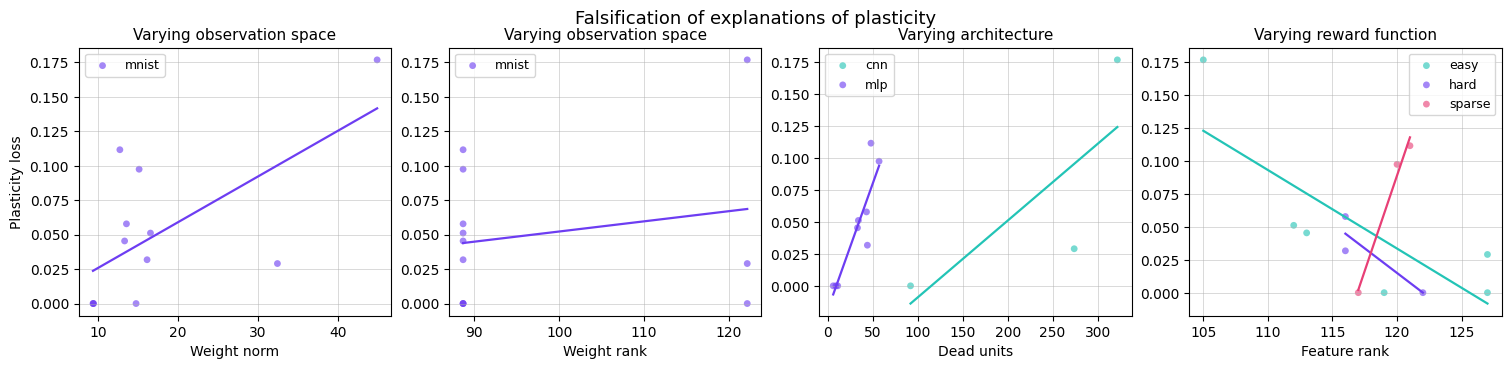

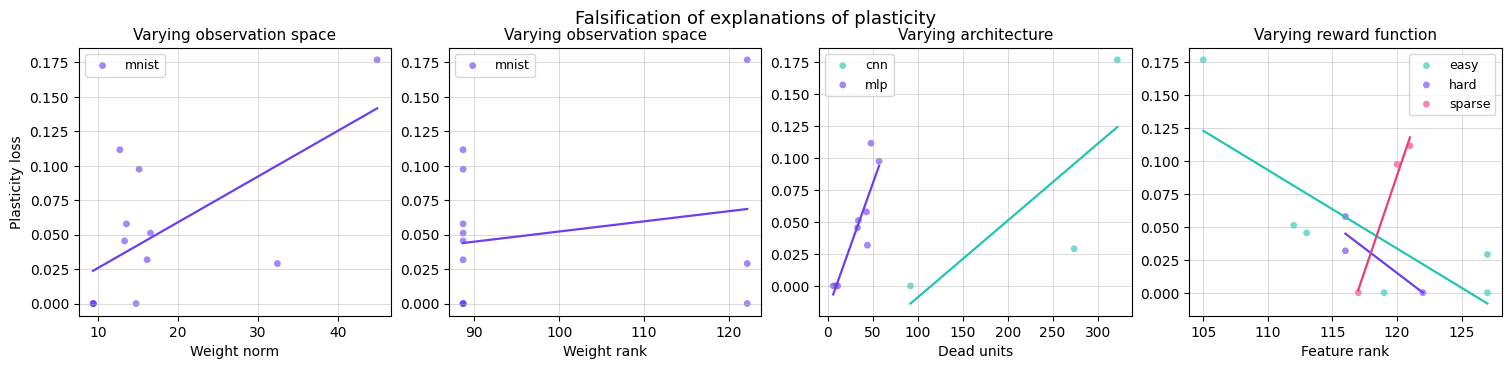

In [13]:
figure_path = FIGURES_DIR / "figure3_falsification_reproduction.png"
fig = plot_figure3(df, save_path=figure_path)
fig

## Paper-Scale Starting Point

Uncomment to run the full sweep (4 seeds x 2 observation spaces x 3 environments, 10,000 training steps each). This downloads MNIST/CIFAR-10 if not already cached and takes substantially longer than the smoke run above.

In [14]:
# paper_configs = make_paper_configs(data_root=str(DATA_ROOT), download=True, seeds=[5, 40, 10, 19])
# paper_df = run_sweep(paper_configs, save_path=TABLES_DIR / "figure3_falsification_summary_paper.csv")
# correlation_summary(paper_df)